# Cell 1 — Imports

In [1]:
import sys
from unittest.mock import MagicMock

sys.modules["langchain_community.chat_models.vertexai"] = MagicMock()

import os
import json
import pandas as pd
import warnings

from datasets import Dataset
from langchain_ollama import ChatOllama
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_ollama import OllamaEmbeddings
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

from ragas import evaluate
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall,
)

load_dotenv()
print(os.getenv("OPENAI_API_KEY")[:15])

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from src.rag_pipeline import ask
print("Import successful")

/home/arun/Desktop/AIProjects/rag-evaluation-framework/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_4066918/1819382949.py:21: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import (
/tmp/ipykernel_4066918/1819382949.py:21: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import (
/tmp/ipykernel_4066918/1819382949.py:21: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated a

sk-proj-6h39ZGS
Import successful


# Cell 2 — Paths

In [2]:
BASE_DIR = os.path.dirname(os.getcwd())

DATASET_PATH    = os.path.join(BASE_DIR, "data", "dataset", "eval_dataset.json")
CHECKPOINT_PATH = os.path.join(BASE_DIR, "data", "dataset", "generated_answers.csv")
RESULTS_PATH    = os.path.join(BASE_DIR, "data", "dataset", "ragas_results.csv")
print (DATASET_PATH)
print (CHECKPOINT_PATH)
print (RESULTS_PATH)

/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/dataset/eval_dataset.json
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/dataset/generated_answers.csv
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/dataset/ragas_results.csv


# Cell 3 — Load dataset

In [3]:
with open(DATASET_PATH, "r", encoding="utf-8") as f:
    eval_data = json.load(f)

print(f"Loaded {len(eval_data)} questions")

Loaded 296 questions


### for testing the variation of chunks

### Experiment tracker

# Cell  Comparing Metrics Across Experiments For Analysis and Understnding

In [22]:
from src.rag_pipeline import vector_store

data = vector_store.get()

print(data.keys())
print(queries)

dict_keys(['ids', 'embeddings', 'documents', 'uris', 'included', 'data', 'metadatas'])
[('What is a transformer?', 0), ('Define a transformer architecture in deep learning', 0), ('Why are transformers efficient?', 6)]


In [25]:

print(type(eval_data))
print(len(eval_data))

print(eval_data[0].keys())
queries = [
    (row["question"], row["chunk_id"])
    for row in eval_data
]

<class 'list'>
296
dict_keys(['question', 'ground_truth', 'source', 'source_type', 'chunk_id', 'chunk_text'])


In [42]:
import pandas as pd
import numpy as np

comparison_rows = []

# -----------------------------
# VECTOR SEARCH
# -----------------------------

for query, expected_chunk in queries:

    results = vector_store.similarity_search_with_score(
        query,
        k=100
    )

    rank_found = None
    expected_score = None

    top_doc, top_score = results[0]
    top_chunk = top_doc.metadata["chunk_id"]

    for rank, (doc, score) in enumerate(results, start=1):

        if doc.metadata["chunk_id"] == expected_chunk:
            rank_found = rank
            expected_score = score
            break

    expected_doc = next(
        doc for doc, meta in zip(
            data["documents"],
            data["metadatas"]
        )
        if meta["chunk_id"] == expected_chunk
    )

    comparison_rows.append({
        "Retriever": "Vector",
        "Query": query,

        "Expected Chunk": expected_chunk,
        "Top Retrieved Chunk": top_chunk,
        "Rank of Expected Chunk": rank_found,
        "Rank Error": (
            rank_found - 1
            if rank_found is not None
            else None
            ),
        "Expected Score": expected_score,

        
        "Top Retrieved Score": top_score,

        "Success": rank_found == 1 if rank_found else False,
        "Recall@1":
            rank_found == 1 if rank_found else False,

        "Recall@5":
            rank_found <= 5 if rank_found else False,

        "Recall@10":
            rank_found <= 10 if rank_found else False,

        "MRR":
            1/rank_found if rank_found else 0,
        "Expected Title":
        chunks[expected_chunk]
            .metadata.get("title"),

        "Retrieved Title":
            top_doc.metadata.get("title"),
        "Expected Chunk Text":
            expected_doc[:400],

        "Top Retrieved Text":
            top_doc.page_content[:400]
    })

# -----------------------------
# BM25 SEARCH
# -----------------------------

for query, expected_chunk in queries:

    tokens = bm25.preprocess_func(query)

    scores = bm25.vectorizer.get_scores(tokens)

    ranked_indices = np.argsort(scores)[::-1]

    top_idx = ranked_indices[0]

    rank_found = None
    score_found = None

    for rank, idx in enumerate(ranked_indices, start=1):

        if chunks[idx].metadata["chunk_id"] == expected_chunk:

            rank_found = rank
            score_found = scores[idx]
            break

    comparison_rows.append({
        "Retriever": "BM25",
        "Query": query,

        "Expected Chunk": expected_chunk,
        "Top Retrieved Chunk":
            chunks[top_idx].metadata["chunk_id"],
        "Rank of Expected Chunk": rank_found,
        "Rank Error": (
            rank_found - 1
            if rank_found is not None
            else None
            ),
        
        "Expected Score": score_found,
        "Top Retrieved Score":
            scores[top_idx],

        "Success": rank_found == 1 if rank_found else False,
        "Recall@1":
            rank_found == 1 if rank_found else False,

        "Recall@5":
            rank_found <= 5 if rank_found else False,

        "Recall@10":
            rank_found <= 10 if rank_found else False,

        "MRR":
            1/rank_found if rank_found else 0,
        "Expected Title":
        chunks[expected_chunk]
            .metadata.get("title"),

        "Retrieved Title":
            top_doc.metadata.get("title"),
        "Expected Chunk Text":
            chunks[expected_chunk].page_content[:400],

        "Top Retrieved Text":
            chunks[top_idx].page_content[:400]
        
    })

comparison_df = pd.DataFrame(
    comparison_rows
)

comparison_df.to_csv(
    "exp01_recursive1000_overlap200_vector_bm25_detailed.csv",
    index=False
)

comparison_df

,Retriever,Query,Expected Chunk,Top Retrieved Chunk,Rank of Expected Chunk,Rank Error,Expected Score,Top Retrieved Score,Success,Recall@1,Recall@5,Recall@10,MRR,Expected Title,Retrieved Title,Expected Chunk Text,Top Retrieved Text
0,Vector,What is a transformer?,0,42,11.0,10.0,0.684334,0.491982,False,False,False,False,0.090909,Transformer (deep learning),Transformer (deep learning),"In deep learning, the transformer is a family ...",Architecture\nAll transformers have the same p...
1,Vector,Why are transformers efficient?,0,42,23.0,22.0,0.808004,0.610822,False,False,False,False,0.043478,Transformer (deep learning),Transformer (deep learning),"In deep learning, the transformer is a family ...",Architecture\nAll transformers have the same p...
2,Vector,What mechanism powers transformers?,0,42,29.0,28.0,0.797702,0.510405,False,False,False,False,0.034483,Transformer (deep learning),Transformer (deep learning),"In deep learning, the transformer is a family ...",Architecture\nAll transformers have the same p...
3,Vector,What is the first step in processing inputs in...,1,121,11.0,10.0,0.641949,0.568426,False,False,False,False,0.090909,Transformer (deep learning),Transformer (deep learning),The original transformer architecture was prop...,Subsequent work\nAlternative activation functi...
4,Vector,What mechanism is used to mix information acro...,1,5,NaN,NaN,NaN,0.542743,False,False,False,False,0.000000,Transformer (deep learning),Transformer (deep learning),The original transformer architecture was prop...,Positional information\nSelf-attention by itse...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
587,BM25,How many steps are involved in mapping input t...,98,21,215.0,214.0,5.107320,17.697142,False,False,False,False,0.004651,Transformer (deep learning),BERT (language model),Subsequent work\nAlternative activation functi...,Tokenization\nAs the transformer architecture ...
588,BM25,What process converts input text to numerical ...,98,21,424.0,423.0,2.148116,12.745244,False,False,False,False,0.002358,Transformer (deep learning),BERT (language model),Subsequent work\nAlternative activation functi...,Tokenization\nAs the transformer architecture ...
589,BM25,What is pretokenization?,99,433,286.0,285.0,1.746828,9.019940,False,False,False,False,0.003497,Transformer (deep learning),BERT (language model),"RoPE\nRoPE (rotary positional embedding), is b...",Theory\nA main criticism concerns the lack of ...
590,BM25,What is the role of the tokenizer?,99,433,697.0,696.0,3.493657,15.783812,False,False,False,False,0.001435,Transformer (deep learning),BERT (language model),"RoPE\nRoPE (rotary positional embedding), is b...",Theory\nA main criticism concerns the lack of ...


In [43]:
summary_df = comparison_df.groupby("Retriever").agg({
    "Recall@1":"mean",
    "Recall@5":"mean",
    "Recall@10":"mean",
    "MRR":"mean",
    "Rank of Expected Chunk":"mean"
}).reset_index()

summary_df.to_csv(
    "exp01_recursive1000_overlap200_summary.csv",
    index=False
)

summary_df

,Retriever,Recall@1,Recall@5,Recall@10,MRR,Rank of Expected Chunk
0,BM25,0.003378,0.013514,0.023649,0.014185,401.442568
1,Vector,0.000000,0.003378,0.006757,0.009345,40.828125


In [44]:
rank_stats = comparison_df[
    comparison_df["Retriever"]=="Vector"
]["Rank of Expected Chunk"].describe()

rank_stats.to_csv(
    "exp01_recursive1000_overlap200_rank_distribution.csv"
)

rank_stats

count    64.000000
mean     40.828125
std      24.730005
min       2.000000
25%      20.250000
50%      37.000000
75%      55.000000
max      96.000000
Name: Rank of Expected Chunk, dtype: float64

In [45]:
experiment_log = pd.DataFrame([{
    "Experiment": "EXP01",

    "Chunking":
        "RecursiveCharacterTextSplitter",

    "Chunk Size":
        1000,

    "Overlap":
        200,

    "Embedding":
        "nomic-embed-text",

    "Vector DB":
        "Chroma",

    "Retriever":
        "Similarity",

    "Questions":
        len(eval_data),

    "Recall@1":
        summary_df[
            summary_df["Retriever"]=="Vector"
        ]["Recall@1"].iloc[0],

    "Recall@5":
        summary_df[
            summary_df["Retriever"]=="Vector"
        ]["Recall@5"].iloc[0],

    "Recall@10":
        summary_df[
            summary_df["Retriever"]=="Vector"
        ]["Recall@10"].iloc[0],

    "MRR":
        summary_df[
            summary_df["Retriever"]=="Vector"
        ]["MRR"].iloc[0],

    "Average Rank":
        summary_df[
            summary_df["Retriever"]=="Vector"
        ]["Rank of Expected Chunk"].iloc[0]
}])

experiment_log.to_csv(
    "experiment_registry.csv",
    index=False
)

experiment_log

,Experiment,Chunking,Chunk Size,Overlap,Embedding,Vector DB,Retriever,Questions,Recall@1,Recall@5,Recall@10,MRR,Average Rank
0,EXP01,RecursiveCharacterTextSplitter,1000,200,nomic-embed-text,Chroma,Similarity,296,0.0,0.003378,0.006757,0.009345,40.828125


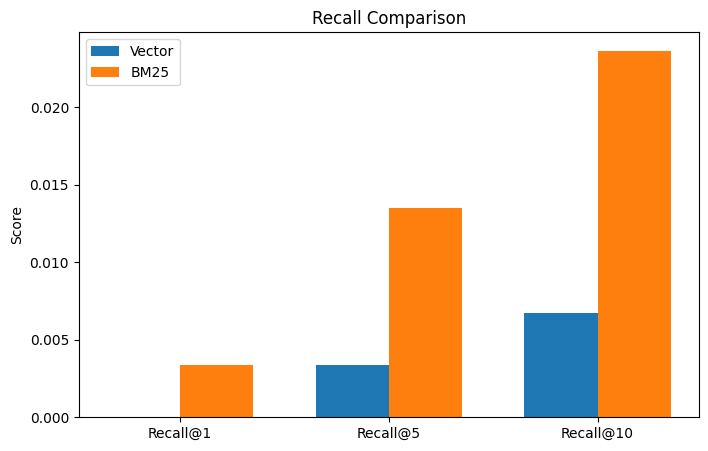

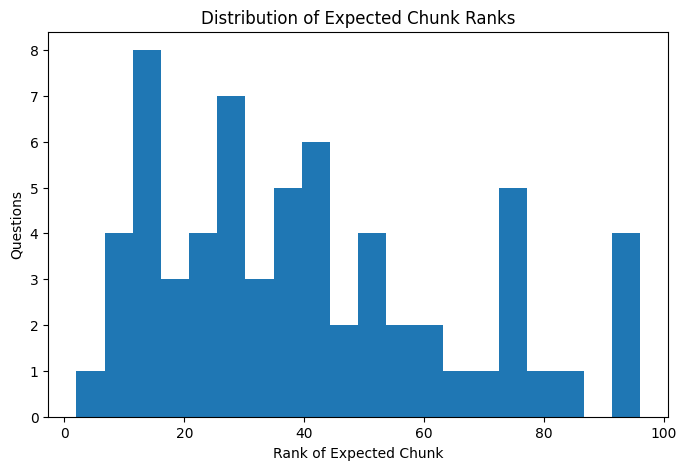

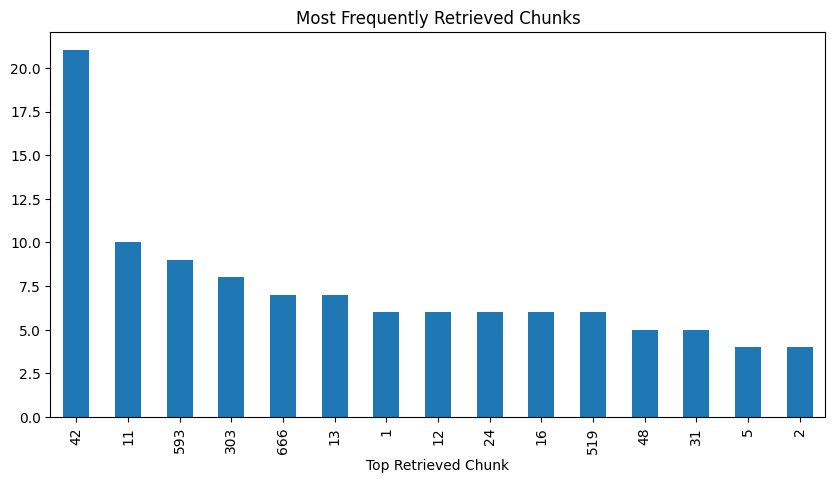

In [48]:
import matplotlib.pyplot as plt

metrics = ["Recall@1", "Recall@5", "Recall@10"]

vector = [0.0, 0.003378, 0.006757]
bm25   = [0.003378, 0.013514, 0.023649]

x = range(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar([i-width/2 for i in x], vector, width, label="Vector")
plt.bar([i+width/2 for i in x], bm25, width, label="BM25")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Recall Comparison")
plt.legend()

#plt.savefig("exp01_recall_comparison.png")
plt.show()


import matplotlib.pyplot as plt

vector_ranks = comparison_df[
    comparison_df["Retriever"]=="Vector"
]["Rank of Expected Chunk"]

plt.figure(figsize=(8,5))

plt.hist(vector_ranks, bins=20)

plt.xlabel("Rank of Expected Chunk")
plt.ylabel("Questions")
plt.title("Distribution of Expected Chunk Ranks")

#plt.savefig(
#    "exp01_rank_distribution.png"
#)

plt.show()




top_chunks = (
    comparison_df[
        comparison_df["Retriever"]=="Vector"
    ]["Top Retrieved Chunk"]
    .value_counts()
    .head(15)
)

top_chunks.plot.bar(
    figsize=(10,5),
    title="Most Frequently Retrieved Chunks"
)

#plt.savefig(
#    "exp01_top_chunks.png"
#)

plt.show()

# Cell 4 — Load checkpoint

In [24]:
completed_questions = set()
results = []

if os.path.exists(CHECKPOINT_PATH):
    existing_df = pd.read_csv(CHECKPOINT_PATH)
    results = existing_df.to_dict("records")
    completed_questions = set(existing_df["question"].dropna())
    print(f"Resuming: {len(completed_questions)}/{len(eval_data)} done")
else:
    print("No checkpoint — starting fresh")

No checkpoint — starting fresh


# Cell 5 — Run RAG loop

In [25]:
for idx, item in enumerate(eval_data):
    question = item["question"]

    if question in completed_questions:
        print(f"[SKIP] {question[:80]}")
        continue

    print(f"[{idx + 1}/{len(eval_data)}] {question[:80]}")

    rag_result = ask(question)

    print("Retrieved Chunks:")
    print(rag_result["retrieved_chunk_ids"])
    
    print("\nAnswer Preview:")
    print(rag_result["answer"][:200])

    row = {
        "question":            question,
        "ground_truth":        item["ground_truth"],
        "chunk_id":            item["chunk_id"],
        "answer":              rag_result["answer"],
        "retrieved_chunk_ids": json.dumps(rag_result["retrieved_chunk_ids"]),
        "contexts":            json.dumps(
                                   [doc.page_content for doc in rag_result["retrieved_docs"]]
                               ),
    }

    results.append(row)
    completed_questions.add(question)
    pd.DataFrame(results).to_csv(CHECKPOINT_PATH, index=False)

    print(
        f"Checkpoint saved: "
        f"{len(results)} rows"
    )

print(f"\nDone. {len(results)} rows saved.")

[1/2] What is a transformer?

RETRIEVED CONTEXT:

Chunk 1
{'source': 'wikipedia', 'chunk_id': 42, 'url': 'https://en.wikipedia.org/wiki/Transformer_(deep_learning)', 'title': 'Transformer (deep learning)'}
Architecture
All transformers have the same primary components:
Chunk 2
{'source': 'wikipedia', 'url': 'https://en.wikipedia.org/wiki/BERT_(language_model)', 'chunk_id': 593, 'title': 'BERT (language model)'}
Architecture
BERT is an "encoder-only" transformer architecture. At a high level, BERT consists of 4 modules:
Chunk 3
{'source': 'wikipedia', 'chunk_id': 142, 'title': 'Transformer (deep learning)', 'url': 'https://en.wikipedia.org/wiki/Transformer_(deep_learning)'}
Efficient implementation
The transformer model has been implemented in standard deep learning frameworks such as TensorFlow and PyTorch. Transformers is a library produced by Hugging Face that supplies transformer-based architectures and pretrained models.
Chunk 4
{'chunk_id': 179, 'url': 'https://en.wikipedia.org/wi

# Cell 6 — Preview checkpoint

In [26]:
answers_df = pd.read_csv(CHECKPOINT_PATH)
answers_df.head()

,question,ground_truth,chunk_id,answer,retrieved_chunk_ids,contexts
0,What is a transformer?,A transformer is a neural network architecture...,0,I don't know based on the provided context.,"[42, 593, 142, 179, 61]","[""Architecture\nAll transformers have the same..."
1,Why are transformers efficient?,They allow parallel processing of tokens.,0,Transformers are efficient because they enable...,"[42, 16, 28, 593, 145]","[""Architecture\nAll transformers have the same..."


# Cell 7 — Build RAGAS Dataset

In [27]:
answers_df.columns.tolist()

['question',
 'ground_truth',
 'chunk_id',
 'answer',
 'retrieved_chunk_ids',
 'contexts']

In [28]:
contexts = [json.loads(c) for c in answers_df["contexts"]]

ragas_dataset = Dataset.from_dict({
    "question":     answers_df["question"].tolist(),
    "answer":       answers_df["answer"].tolist(),
    "contexts":     contexts,
    "ground_truth": answers_df["ground_truth"].tolist(),
})

print(ragas_dataset)

Dataset({
    features: ['question', 'answer', 'contexts', 'ground_truth'],
    num_rows: 2
})


# Cell 8 — Configure LLM + embeddings

In [52]:
evaluator_llm = LangchainLLMWrapper(
    ChatOpenAI(
        model="gpt-4o-mini",
        temperature=0
    )
)

evaluator_embeddings = LangchainEmbeddingsWrapper(
    OllamaEmbeddings(model="nomic-embed-text")
)

faithfulness.llm            = evaluator_llm
answer_relevancy.llm        = evaluator_llm
answer_relevancy.embeddings = evaluator_embeddings
context_precision.llm       = evaluator_llm
context_recall.llm          = evaluator_llm

# Cell 9 — Evaluate

### faithfulness

In [45]:
faithfulness_result = evaluate(
    ragas_dataset,
    metrics=[faithfulness]
)

faithfulness_score = faithfulness_result["faithfulness"]
print(faithfulness_score)

Evaluating: 100%|████████████████████████████████████████████████████████████████████| 2/2 [02:01<00:00, 60.98s/it]


### answer relevancy

In [47]:
answer_relevancy_result = evaluate(
    ragas_dataset,
    metrics=[answer_relevancy]
)

answer_relevancy_score = answer_relevancy_result["answer_relevancy"]
print(answer_relevancy_score)

Evaluating: 100%|████████████████████████████████████████████████████████████████████| 2/2 [02:06<00:00, 63.43s/it]


[nan, nan]


### context precision

0.4.3


In [53]:
context_precision_result = evaluate(
    ragas_dataset,
    metrics=[context_precision]
)

context_precision_score = context_precision_result["context_precision"]
print(context_precision_score)

Evaluating:   0%|                                                                            | 0/2 [00:00<?, ?it/s]Exception raised in Job[0]: TimeoutError()
Exception raised in Job[1]: TimeoutError()
Evaluating: 100%|████████████████████████████████████████████████████████████████████| 2/2 [03:03<00:00, 91.58s/it]


[nan, nan]


In [58]:
answers_df[
    ["question", "answer", "ground_truth"]
]

,question,answer,ground_truth
0,What is a transformer?,I don't know based on the provided context.,A transformer is a neural network architecture...
1,Why are transformers efficient?,Transformers are efficient because they enable...,They allow parallel processing of tokens.


In [59]:
print(type(context_precision))
print(evaluator_llm)

single_dataset = Dataset.from_dict({
    "question": [ragas_dataset["question"][1]],
    "answer": [ragas_dataset["answer"][1]],
    "contexts": [ragas_dataset["contexts"][1]],
    "ground_truth": [ragas_dataset["ground_truth"][1]]
})

result = evaluate(
    single_dataset,
    metrics=[context_precision]
)

print(result)

<class 'ragas.metrics._context_precision.ContextPrecision'>
LangchainLLMWrapper(langchain_llm=ChatOpenAI(...))


Evaluating: 100%|███████████████████████████████████████████████████████████████████| 1/1 [03:04<00:00, 184.81s/it]


{'context_precision': 0.5000}


### Context Recall

In [40]:
context_recall_result = evaluate(
    ragas_dataset,
    metrics=[context_recall]
)

context_recall_score = context_recall_result["context_recall"]
print(context_recall_score)

Evaluating: 100%|████████████████████████████████████████████████████████████████████| 2/2 [01:26<00:00, 43.16s/it]


[0.0, 1.0]


### Combine metric results

In [ ]:
result = {
    "faithfulness": faithfulness_score,
    "answer_relevancy": answer_relevancy_score,
    "context_precision": context_precision_score,
    "context_recall": context_recall_score
}

result

# Cell 10 — Save results

In [ ]:
result_df = result.to_pandas()
result_df.insert(0, "question",     answers_df["question"].values)
result_df.insert(1, "chunk_id",     answers_df["chunk_id"].values)
result_df.insert(2, "ground_truth", answers_df["ground_truth"].values)

result_df.to_csv(RESULTS_PATH, index=False)

print(result_df[["faithfulness", "answer_relevancy", "context_precision", "context_recall"]].mean().round(4))
display(result_df.head())